### 데이터 병합


In [1]:
import pandas as pd

df_origin_1 = pd.read_csv("./data/raw/raw_race_2023_to_20260426.csv")
df_origin_2 = pd.read_csv("./data/raw/horse_info.csv")

# raw 데이터 합치기
df_merged = df_origin_1.merge(df_origin_2, on="hrno", how="left")

# 파일 저장
df_merged.to_csv("./data/prepro/0_merged_data.csv", index=False, encoding="utf-8-sig")

df_merged.head(1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6500\629845868.py:3: DtypeWarning: Columns (0: jkNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df_origin_1 = pd.read_csv("./data/raw/raw_race_2023_to_20260426.csv")


,chaksun,diffTot,divide,hrName,hrno,jkName,jkNo,noracefl,prow,prowName,...,ppseNm,prodNm,rchrRegCnclDt,rchrRegDt,sireHrnm,sitlNm,spcsNm,studbook,hrno_request,status
0,2000000,12.25,0,새내칸,45818,이혁,080486,정상,117013.0,문금철,...,승용,김준현,2026-02-23,2022-04-15,선더모카신,에프엠농장(김만영),더러브렛,-,45818,ok


### 컬럼 한글화


In [2]:
df_merged.rename(
    columns={
        "chaksun": "착순상금",
        "diffTot": "전체_누적_도착차",
        "divide": "분할경주여부",
        "hrNam": "마명",
        "hrName": "마명",
        "rcChul": "출전번호",
        "rcCode": "대상경주명",
        "rcDate": "경주일자",
        "hrno": "마번",
        "jkNam": "기수명",
        "jkName": "기수명",
        "jkNo": "기수번호",
        "meet": "경마장명",
        "noracefl": "경주취소여부",
        "prow": "마주번호",
        "prowNam": "마주명",
        "prowName": "마주명",
        "prtr": "조교사번호",
        "prtrNam": "조교사명",
        "prtrName": "조교사명",
        "rankKind": "경주종류",
        "rc10dusu": "예상배당율",
        "rcAge": "연령조건",
        "rcBudam": "부담구분",
        "rcDiff2": "2순위별누적착자",
        "rcDiff3": "3순위별누적착자",
        "rcDiff4": "4순위별누적착자",
        "rcDiff5": "5순위별누적착자",
        "rcDist": "경주거리",
        "rcFrflag": "경주구분",
        "rcGrade": "경주등급",
        "rcHrfor": "국산외산마구분",
        "rcHrnew": "출전마구분",
        "rcNo": "경주번호",
        "rcNrace": "야간경마여부",
        "rcOrd": "순위",
        "rcP1Odd": "확정배당율_단승식",
        "rcP1Sale": "확정배당금액_단승식",
        "rcP2Odd": "확정배당율_연승식",
        "rcP2Sale": "확정배당금액_연승식",
        "rcP3Odd": "확정배당율_복승식",
        "rcP3Sale": "확정배당금액_복승식",
        "rcP4Odd": "확정배당율_쌍승식",
        "rcP4Sale": "확정배당금액_쌍승식",
        "rcP5Odd": "확정배당율_복연승식",
        "rcP5Sale": "확정배당금액_복연승식",
        "rcP6Odd": "확정배당율_삼복승식",
        "rcP6Sale": "확정배당금액_삼복승식",
        "rcP8Odd": "확정배당율_삼쌍승식",
        "rcP8Sale": "확정배당금액_삼쌍승식",
        "rcPlansu": "편성두수",
        "rcRank": "마필등급",
        "rcSex": "성별조건",
        "rcSpcba": "경주종류코드",
        "rcSpcbu": "경주등급구분",
        "rcTime": "경주기록",
        "rcVtdusu": "출주두수",
        "rundayth": "경주일수",
        "track": "경주로상태",
        "weath": "날씨",
        "wgHr": "마체중",
        "korHrnm": "마명",
        "microNo": "마이크로칩번호",
        "owrNm": "소유자명",
        "sitlNm": "소재지",
        "prodNm": "생산자",
        "hrnmGrtDt": "마명부여일",
        "ppseNm": "최종용도",
        "horseCtcolNm": "마필털색",
        "bldlnRegDt": "혈통등록일",
        "pctyNm": "생산국",
        "studbook": "혈통서",
        "rchrRegDt": "경주마등록일",
        "rchrRegCnclDt": "경주마취소일",
        "imphrEngHrnm": "원마명",
        "gndrNm": "성별",
        "fdtRegDt": "기초등록일자",
        "ihrno": "국제마번",
        "passport": "패스포트",
        "sireHrnm": "부마명",
        "foalgDt": "출생일",
        "orcpyDt": "폐사일",
        "spcsNm": "품종",
        "bredgRegDt": "번식등록일",
        "indcCtryNm": "수입국",
        "damHrnm": "모마명",
        "hrnm": "마명",
        "etc": "기타",
        "hrsHeadChticTxt": "머리",
        "hrsNeckChticTxt": "목",
        "hrsBodyChticTxt": "몸통",
        "etcChticTxt": "기타",
        "hrsEtcPntsBrandShaTxt": "기타낙인",
    },
    inplace=True,
)

# 파일 저장
df_merged.to_csv(
    "./data/prepro/1_merged_data_kr.csv", index=False, encoding="utf-8-sig"
)

### 파생 변수 생성 및 불필요 데이터 제거

- 🚨 파생 변수 사용 이유 증명 필요


In [3]:
df_merged_kr = pd.read_csv("./data/prepro/1_merged_data_kr.csv")

# =======================================================================
# 경주취소여부 = 취소 row 삭제
# 취소된 경주 데이터는 가치가 없음
df_merged_kr = df_merged_kr.query("경주취소여부 != '취소'")

# -----------------------------------------------------------------------
# 야간경마여부 = 야간경마 row 삭제
# 야간경마 비율이 7%로 큰 의미 없으나 복잡도만 높아짐
# 모델 전제조건에 야간경마는 제외
df_merged_kr = df_merged_kr.query("야간경마여부 != '야간경마'")

# -----------------------------------------------------------------------
# 순위가 17위 이상은 비정상 데이터이므로 삭제
df_merged_kr = df_merged_kr.query("순위 < 17")

# -----------------------------------------------------------------------
# 🚨 결론: 이 컬럼들은 피처(X)에서 삭제해야 합니다
# 이 데이터가 '결과 데이터'라는 강력한 증거는 다음과 같습니다.

# 시계열 역전 불가능: 경주 전에는 그날 2등이 몇 마신 차이로 들어올지 알 수 없습니다.

# 데이터 누수(Data Leakage): 만약 모델이 이 값을 알게 되면, "아, 오늘 2순위 착차가 0.25네? 그럼 다닥다닥 붙어 뛰는 접전이구나" 같은 경주 결과를 미리 보고 순위를 예측하게 되어 실전에서는 전혀 쓸모없는 모델이 됩니다.
# 결과 데이터(Leakage) 성격이 강한 컬럼들 삭제
leakage_cols = [
    "2순위별누적착자",
    "3순위별누적착자",
    "4순위별누적착자",
    "5순위별누적착자",
    "전체_누적_도착차",
    "착순상금",  # 상금도 결과값이니 삭제 대상입니다
]

df_merged_kr.drop(columns=leakage_cols, inplace=True, errors="ignore")

# -----------------------------------------------------------------------
# '국산외산마구분' 컬럼을 1(국산마)과 0(외산마)으로 변환
df_merged_kr["국산외산마구분"] = df_merged_kr["국산외산마구분"].map(
    {"국산마": 1, "외산마": 0}
)

# -----------------------------------------------------------------------
# 신마_여부 컬럼 생성 (해당 항목에 속하면 1, 아니면 0)
df_merged_kr["신마_여부"] = (
    df_merged_kr["출전마구분"]
    .isin(
        # 신인급 경주로 분류할 항목 리스트 정의
        ["루키", "Rookie2", "세컨드챌린지", "육성심사합격마"],
    )
    .astype(int)
)

# -----------------------------------------------------------------------
# 1. '경주일자'를 datetime 타입으로 먼저 변환 (숫자/문자열 모두 대응 가능)
df_merged_kr["경주일자"] = pd.to_datetime(
    df_merged_kr["경주일자"].astype(str), format="%Y%m%d"
)

# 2. 원하는 포맷(yyyy-MM-dd)의 문자열로 변경
df_merged_kr["경주일자"] = df_merged_kr["경주일자"].dt.strftime("%Y-%m-%d")

# -----------------------------------------------------------------------
# '출생일' 컬럼에서 앞의 10자리(yyyy-MM-dd)만 추출
df_merged_kr["출생일"] = df_merged_kr["출생일"].str[:10]

# -----------------------------------------------------------------------
# datetime으로 임시 변환하여 개월 수 차이 계산
temp_race_date = pd.to_datetime(df_merged_kr["경주일자"])
temp_birth_date = pd.to_datetime(df_merged_kr["출생일"])

# 개월 수 계산 (날짜 차이 / 30.44일)
df_merged_kr["마필_개월수"] = (
    (temp_race_date - temp_birth_date).dt.days / 30.44  # type: ignore
).astype(int)

# -----------------------------------------------------------------------
# 1 <= 마필등급 <= 6 인 데이터만 유지
df_merged_kr = df_merged_kr.query("1 <= 마필등급 <= 6")

# -----------------------------------------------------------------------
# 경주별 평균 체중 대비 차이 피처 생성
# 양수 (+): 해당 경주에서 평균보다 무거운 말 (체격이 좋아 힘이 좋을 가능성)
# 음수 (-): 해당 경주에서 평균보다 가벼운 말 (몸집이 작아 날렵할 가능성)
df_merged_kr["경주_상대적_마체중"] = df_merged_kr.groupby(["경주일자", "경주번호"])[
    "마체중"
].transform(lambda x: x - x.mean())

# =======================================================================
# 컬럼 드랍
df_pp_1 = df_merged_kr.drop(
    columns=[
        # 경주취소 로직은 위에서 적용했으므로 이 컬럼은 제거
        "경주취소여부",
        # 마번 항목이 있으므로 불필요함
        "마명",
        # 기수번호 항목이 있으므로 불필요함
        "기수명",
        # 마주번호 항목이 있으므로 불필요함
        "마주명",
        # 조교사번호 항목이 있으므로 불필요함
        "조교사명",
        # 의미있는 데이터가 아님
        "연령조건",
        "대상경주명",
        "경주구분",
        "경주등급",
        "편성두수",
        "성별조건",
        "경주일수",
        "혈통등록일",
        "번식등록일",
        "기타",
        "기초등록일자",
        "마필털색",
        "마명부여일",
        "몸통",
        "기타낙인",
        "머리",
        "목",
        "국제마번",
        "원마명",
        "수입국",
        "마명.1",
        "마이크로칩번호",
        "패스포트",
        "최종용도",
        "경주마취소일",
        "경주마등록일",
        "품종",
        "혈통서",
        "hrno_request",
        "status",
        # 출전마 구분을 신마_여부 로 단순화했으므로 이 컬럼은 제거
        "출전마구분",
        # 로직은 위에서 처리함, 이 컬럼은 제거
        "야간경마여부",
        # 폐사한 말도 유의미한 과거 데이터이므로, 컬럼만 제거하고 row는 유지
        "폐사일",
        # 배당 관련 (단승/복승 등 모든 배당): 배당률은 '경주 결과'에 대한 대중의 집단지성입니다. 이걸 넣으면 모델은 배당이 낮은 놈이 1등이라는 것만 학습합니다.
        "확정배당율_단승식",
        "확정배당금액_단승식",
        "확정배당율_연승식",
        "확정배당금액_연승식",
        "확정배당율_복승식",
        "확정배당금액_복승식",
        "확정배당율_쌍승식",
        "확정배당금액_쌍승식",
        "확정배당율_복연승식",
        "확정배당금액_복연승식",
        "확정배당율_삼복승식",
        "확정배당금액_삼복승식",
        "확정배당율_삼쌍승식",
        "확정배당금액_삼쌍승식",
        # 경주기록: y값인 순위와 거의 1:1 대응되는 정보입니다.
        #"경주기록",
    ]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6500\3239047895.py:1: DtypeWarning: Columns (0: 기수번호) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged_kr = pd.read_csv("./data/prepro/1_merged_data_kr.csv")


In [4]:
df_pp_1.columns

Index(['분할경주여부', '마번', '기수번호', '마주번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주거리',
       '국산외산마구분', '경주번호', '순위', '마필등급', '경주등급구분', '경주기록', '출주두수', '경주로상태',
       '날씨', '마체중', '모마명', '출생일', '성별', '소유자명', '생산국', '생산자', '부마명', '소재지',
       '신마_여부', '마필_개월수', '경주_상대적_마체중'],
      dtype='str')

In [5]:
df=df_pp_1.copy()

#### ~~~~~~~~~~~~파생변수 만들기

In [18]:
import numpy as np

# -------------------------------------------------
# 정렬 (경주 기준)
df = df.sort_values(["경주일자", "경주번호"])
group_cols = ["경주일자", "경주번호"]

# -------------------------------------------------
# 1. 체중 기반 (가장 강력한 신호 중 하나)
df["경주_평균체중"] = df.groupby(group_cols)["마체중"].transform("mean")
df["경주_대비_체중"] = df["마체중"] - df["경주_평균체중"]

df["체중_rank"] = df.groupby(group_cols)["마체중"]\
    .rank(method="min", ascending=False)

# 표준화
df["경주_체중_std"] = df.groupby(group_cols)["마체중"].transform("std")
df["경주_정규화_체중"] = df["경주_대비_체중"] / (df["경주_체중_std"] + 1e-6)

# -------------------------------------------------
# 2. 나이(개월수) 기반
df["경주_평균개월수"] = df.groupby(group_cols)["마필_개월수"].transform("mean")
df["경주_대비_개월수"] = df["마필_개월수"] - df["경주_평균개월수"]

df["개월수_rank"] = df.groupby(group_cols)["마필_개월수"]\
    .rank(method="min", ascending=False)

# -------------------------------------------------
# 3. 등급 기반
df["경주_평균등급"] = df.groupby(group_cols)["마필등급"].transform("mean")
df["경주_대비_등급"] = df["마필등급"] - df["경주_평균등급"]

df["등급_rank"] = df.groupby(group_cols)["마필등급"]\
    .rank(method="min", ascending=True)  # 낮을수록 좋음

# -------------------------------------------------
# 4. 체중 + 나이 조합 (중요)
df["체중_나이비율"] = df["마체중"] / (df["마필_개월수"] + 1)

# -------------------------------------------------
# 5. 신마 패널티
df["신마_패널티"] = df["신마_여부"] * df["출주두수"]

# -------------------------------------------------
# 6. Softmax 확률 (Top1 핵심 ⭐)
def softmax(x):
    e = np.exp(x - x.mean())
    return e / e.sum()

df["체중_softmax"] = df.groupby(group_cols)["마체중"].transform(softmax)
df["개월수_softmax"] = df.groupby(group_cols)["마필_개월수"].transform(softmax)

# -------------------------------------------------
# 7. 경쟁 강도
df["출주두수_inverse"] = 1 / df["출주두수"]

df["이전기록"] = df.groupby("마번")["경주기록"].shift(1)


df["최근3경기"] = (
    df.groupby("마번")["경주기록"]
    .shift(1)
    .rolling(3)
    .mean()
)


df["전체평균"] = (
    df.groupby("마번")["경주기록"]
    .shift(1)
    .expanding()
    .mean()
)

In [19]:
df_pp_1=df.copy()

In [20]:
# =======================================================================
# 파일저장
df_pp_1.to_csv(
    "./data/prepro/2_pp.csv",
    index=False,
    encoding="utf-8-sig",
)

In [21]:
df_pp_1.columns

Index(['분할경주여부', '마번', '기수번호', '마주번호', '조교사번호', '부담구분', '출전번호', '경주일자', '경주거리',
       '국산외산마구분', '경주번호', '순위', '마필등급', '경주등급구분', '경주기록', '출주두수', '경주로상태',
       '날씨', '마체중', '모마명', '출생일', '성별', '소유자명', '생산국', '생산자', '부마명', '소재지',
       '신마_여부', '마필_개월수', '경주_상대적_마체중', '경주_평균체중', '경주_대비_체중', '체중_rank',
       '경주_체중_std', '경주_정규화_체중', '경주_평균개월수', '경주_대비_개월수', '개월수_rank',
       '경주_평균등급', '경주_대비_등급', '등급_rank', '체중_나이비율', '신마_패널티', '체중_softmax',
       '개월수_softmax', '출주두수_inverse', '이전기록', '최근3경기', '전체평균'],
      dtype='str')

### 학습


In [22]:
import pandas as pd
from lightgbm import LGBMRanker, early_stopping

df_pp_1 = pd.read_csv("./data/prepro/2_pp.csv")

# -----------------------------
# 1. 시간 기준 split (핵심)
# -----------------------------
df_pp_1 = df_pp_1.sort_values(["경주일자", "경주번호"])


# 문자열 컬럼들 카테고리화
for col in ["경주로상태", "날씨", "성별"]:
    df_pp_1[col] = df_pp_1[col].astype("category")

train_df = df_pp_1[df_pp_1["경주일자"] < "2026-01-01"].copy()
test_df = df_pp_1[df_pp_1["경주일자"] >= "2026-01-01"].copy()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6500\3082096924.py:4: DtypeWarning: Columns (0: 기수번호) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pp_1 = pd.read_csv("./data/prepro/2_pp.csv")


#### ~~~~~~~~~~~~ 새로운 feature 값 넣기

In [23]:
features = [
    # 기본
    "경주거리",
    "출주두수",
    "경주로상태",
    "날씨",
    "성별",
    "국산외산마구분",
    "경주등급구분",

    # 핵심 원본
    "마체중",
    "마필_개월수",
    "마필등급",
    "경주_상대적_마체중",
    "신마_여부",

    # -----------------------------
    # 🔥 Top1 핵심 파생
    # -----------------------------
    "경주_대비_체중",
    "체중_rank",
    "경주_정규화_체중",

    "경주_대비_개월수",
    "개월수_rank",

    "경주_대비_등급",
    "등급_rank",

    "체중_나이비율",
    "신마_패널티",

    "체중_softmax",
    "개월수_softmax",

    "출주두수_inverse",

    "전체평균",
    "최근3경기",
    "이전기록"
]

In [12]:
'''
# -----------------------------
# 2. feature 정의
# -----------------------------
features = [
    "분할경주여부",
    "부담구분",
    "출전번호",
    "경주거리",
    "국산외산마구분",
    "마필등급",
    "경주등급구분",
    "출주두수",
    "경주로상태",
    "날씨",
    "마체중",
    "성별",
    "신마_여부",
]
'''

'\n# -----------------------------\n# 2. feature 정의\n# -----------------------------\nfeatures = [\n    "분할경주여부",\n    "부담구분",\n    "출전번호",\n    "경주거리",\n    "국산외산마구분",\n    "마필등급",\n    "경주등급구분",\n    "출주두수",\n    "경주로상태",\n    "날씨",\n    "마체중",\n    "성별",\n    "신마_여부",\n]\n'

In [26]:
X_train = train_df[features]
# 1등이 가장 큰 값을 갖도록 변환 (예: 12두 경주 1등 -> 12점)
y_train = train_df["출주두수"] - train_df["순위"] + 1

X_test = test_df[features]
# 1등이 가장 큰 값을 갖도록 변환 (예: 12두 경주 1등 -> 12점)
y_test = test_df["출주두수"] - test_df["순위"] + 1


# -----------------------------
# 3. group 생성 (경주 단위)
# -----------------------------
train_groups = train_df.groupby(["경주일자", "경주번호"]).size().to_list()
test_groups = test_df.groupby(["경주일자", "경주번호"]).size().to_list()

# -----------------------------
# 4. 모델 생성
# -----------------------------

# 정밀 튜닝 버전
model = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=50,  # 트리를 조금 더 늘려보되
    learning_rate=0.02,  # 더 천천히 꼼꼼하게 학습
    max_depth=4,  # 깊이는 여전히 제한해서 과적합 방지
    num_leaves=10,  # 복잡도 조절
    min_child_samples=100,  # 노드 분할 시 최소 데이터 수 (안정성 향상)
    subsample=0.8,  # 데이터 샘플링으로 일반화 유도
    colsample_bytree=0.7,  # 피처 샘플링으로 특정 피처(기수 등) 의존도 분산
    reg_alpha=0.5,  # L1 규제 강화
    reg_lambda=1.4,  # L2 규제 강화
)

# -----------------------------
# 5. 학습
# -----------------------------
model.fit(
    X_train,
    y_train,
    group=train_groups,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_group=[train_groups, test_groups],
    # 50회 동안 Test NDCG가 안 오르면 멈춤
    callbacks=[early_stopping(stopping_rounds=50)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2964
[LightGBM] [Info] Number of data points in the train set: 29388, number of used features: 27
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1]	training's ndcg@1: 0.329079	training's ndcg@2: 0.390446	training's ndcg@3: 0.441558	training's ndcg@4: 0.489576	training's ndcg@5: 0.531722	valid_1's ndcg@1: 0.367688	valid_1's ndcg@2: 0.420636	valid_1's ndcg@3: 0.465724	valid_1's ndcg@4: 0.508728	valid_1's ndcg@5: 0.548004


,boosting_type,'gbdt'
,num_leaves,10
,max_depth,4
,learning_rate,0.02
,n_estimators,50
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


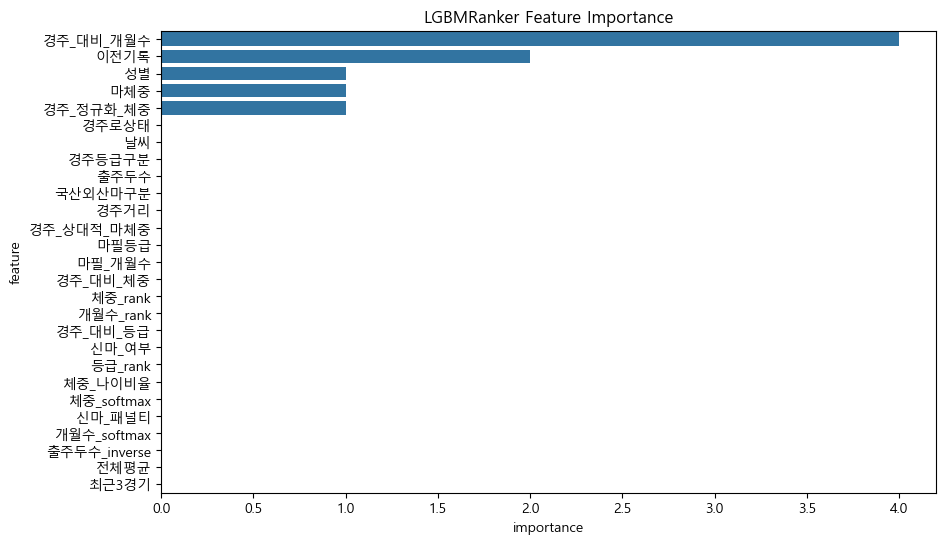

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트
# plt.rcParams["font.family"] = "Pretendard"  # 한글 폰트
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

# Feature Importance 시각화
feature_importance = pd.DataFrame(
    {"feature": features, "importance": model.feature_importances_}
)
feature_importance = feature_importance.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance)
plt.title("LGBMRanker Feature Importance")
plt.show()

In [28]:
print(feature_importance)

         feature  importance
15     경주_대비_개월수           4
26          이전기록           2
4             성별           1
7            마체중           1
14     경주_정규화_체중           1
2          경주로상태           0
3             날씨           0
6         경주등급구분           0
1           출주두수           0
5        국산외산마구분           0
0           경주거리           0
10    경주_상대적_마체중           0
9           마필등급           0
8         마필_개월수           0
12      경주_대비_체중           0
13       체중_rank           0
16      개월수_rank           0
17      경주_대비_등급           0
11         신마_여부           0
18       등급_rank           0
19       체중_나이비율           0
21    체중_softmax           0
20        신마_패널티           0
22   개월수_softmax           0
23  출주두수_inverse           0
24          전체평균           0
25         최근3경기           0


In [29]:
# 1. 테스트 데이터에 대한 예측 점수 산출
test_df["pred_score"] = model.predict(X_test)  # type: ignore

# 2. 경주별 예측 순위(pred_rank) 생성
# 점수가 높을수록(ascending=False) 1위에 가깝게 순위를 매깁니다.
test_df["pred_rank"] = test_df.groupby(["경주일자", "경주번호"])["pred_score"].rank(
    ascending=False, method="first"
)


# ---------------------------------------------------------
# 3. Hit@K 계산 (상위 K위 안에 실제 1위가 포함될 확률)
# ---------------------------------------------------------
def get_hit_at_k(df, k):
    # 모델이 상위 k위로 예측한 말들만 추출
    top_k = df[df["pred_rank"] <= k]
    # 각 경주별로 실제 1위(순위==1)가 포함되어 있는지 체크
    hits = top_k.groupby(["경주일자", "경주번호"])["순위"].apply(
        lambda x: (x == 1).any()
    )
    return hits.mean()


hit_1 = get_hit_at_k(test_df, 1)
hit_3 = get_hit_at_k(test_df, 3)
hit_5 = get_hit_at_k(test_df, 5)

# ---------------------------------------------------------
# 4. 모델 1순위 추천마의 실제 입상률 (3등 내 진입 확률)
# ---------------------------------------------------------
# 모델이 1위로 찍은 말(pred_rank == 1)이 실제로 3위 안에 들었는지 계산
top1_in_the_money = (
    test_df[test_df["pred_rank"] == 1]["순위"].apply(lambda x: x <= 3).mean()
)

# 5. 결과 출력
print(f"🎯 모델의 1등 적중률 (Hit@1): {hit_1:.2%}")
print(f"🥉 상위 3위 내 1등 포함 확률 (Hit@3): {hit_3:.2%}")
print(f"🖐️ 상위 5위 내 1등 포함 확률 (Hit@5): {hit_5:.2%}")
print("-" * 40)
print(f"🐎 모델 1순위 추천마의 실제 입상률(3등 내): {top1_in_the_money:.2%}")

🎯 모델의 1등 적중률 (Hit@1): 23.89%
🥉 상위 3위 내 1등 포함 확률 (Hit@3): 52.51%
🖐️ 상위 5위 내 1등 포함 확률 (Hit@5): 71.09%
----------------------------------------
🐎 모델 1순위 추천마의 실제 입상률(3등 내): 52.80%


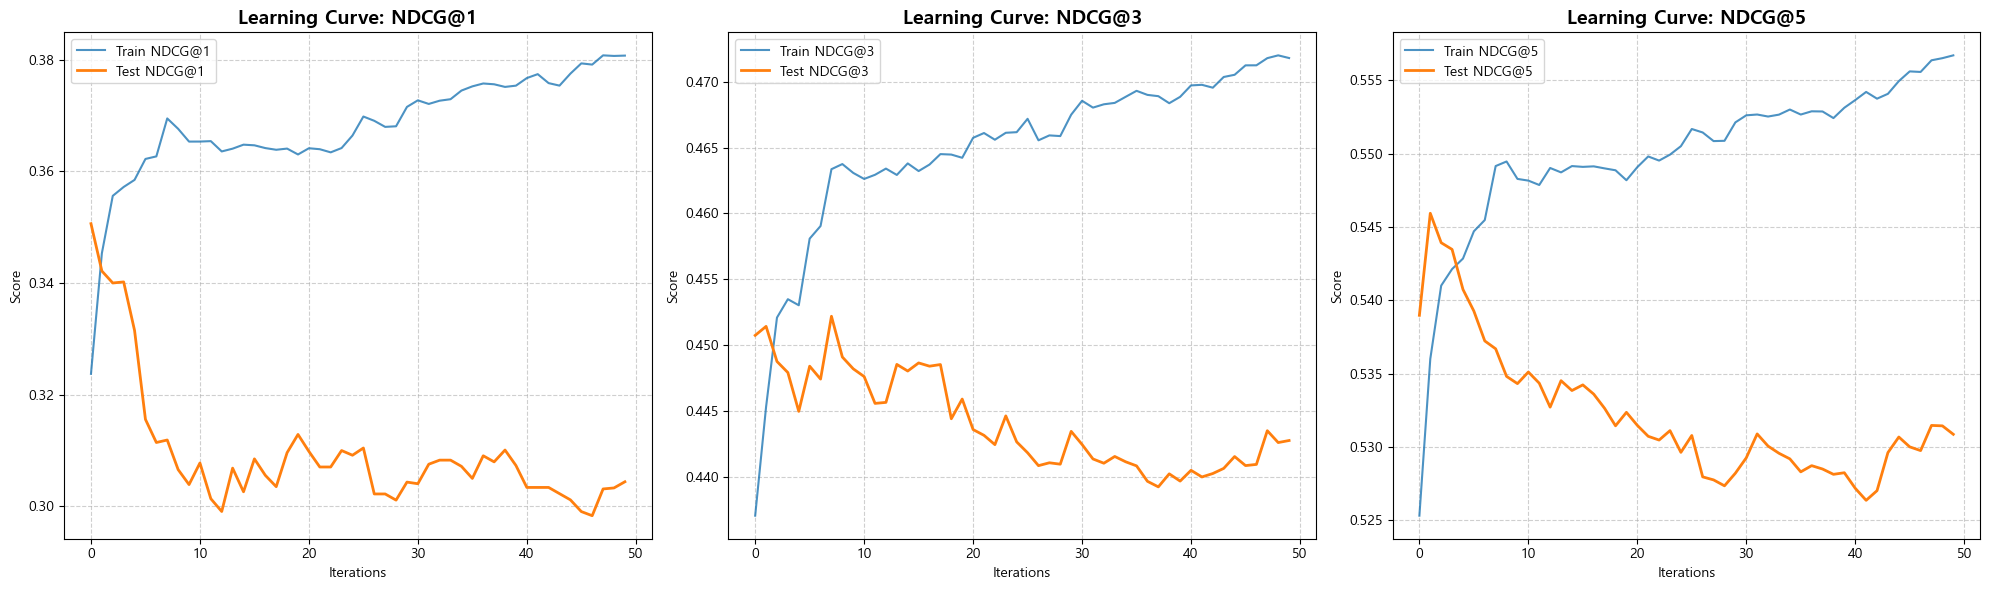

In [17]:
import matplotlib.pyplot as plt

# 1. 학습 로그 추출
results = model.evals_result_

# eval_set 키 확인 (훈련/테스트 세트)
keys = list(results.keys())
train_key, test_key = keys[0], keys[1]

# 2. 메트릭 리스트 준비
metrics = ["ndcg@1", "ndcg@3", "ndcg@5"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # 1행 3열 구성

for i, m in enumerate(metrics):
    axes[i].plot(
        results[train_key][m], label=f"Train {m.upper()}", color="tab:blue", alpha=0.8
    )
    axes[i].plot(
        results[test_key][m], label=f"Test {m.upper()}", color="tab:orange", linewidth=2
    )

    axes[i].set_title(f"Learning Curve: {m.upper()}", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Iterations")
    axes[i].set_ylabel("Score")
    axes[i].legend()
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']